# Undertake sensitivity analysis and optimisation

model_optimisation_env

### import packages

In [1]:
%%time

import sys
import os
import numpy as np
import pandas as pd
import scipy as sci
from scipy.stats import gaussian_kde, skew, pearsonr
from scipy.special import expit, logit
import random

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import cmocean.cm as cmo
from cmocean.tools import lighten
import seaborn as sns

import SALib as SAL
from SALib.sample import saltelli
from SALib.analyze import sobol

import sklearn as skl
from sklearn import gaussian_process
from sklearn.gaussian_process.kernels import Matern,WhiteKernel,ConstantKernel,RBF
from sklearn.gaussian_process.kernels import DotProduct,ExpSineSquared,RationalQuadratic
from sklearn.utils import resample
from sklearn.metrics import r2_score

import joblib
from joblib import Parallel, delayed
from multiprocessing import Pool

import emcee

import warnings
warnings.filterwarnings('ignore')

# print versions of packages
print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("pandas version =", pd.__version__)
print("scipy version =", sci.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("sklearn version =", skl.__version__)
print("SALib version =", SAL.__version__)
print("seaborn version =", sns.__version__)
print("emcee version =", emcee.__version__)


wrkdir="/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/"
os.chdir(wrkdir)
os.getcwd()
os.listdir()

python version = 3.10.
numpy version = 1.26.4
pandas version = 2.3.3
scipy version = 1.15.3
matplotlib version = 3.10.6
cmocean version = v3.0.3
sklearn version = 1.7.2
SALib version = 1.4.7
seaborn version = 0.13.2
emcee version = 3.1.6
CPU times: user 2.73 s, sys: 1.94 s, total: 4.67 s
Wall time: 47.4 s


['BIAS_optimal.xlsx',
 'BIAS.xlsx',
 'GPR_pco2_cost.joblib',
 'GPR_pco2_rmse.joblib',
 'NSDEV.xlsx',
 'NRMSE_optimal.xlsx',
 'parameter_ranges.xlsx',
 'GPR_chl_bottle_corr.joblib',
 'GPR_bac_corr.joblib',
 'parameter_norm_optimal100_2.txt',
 'parameter_sets_optimal100_2.txt',
 'GPR_micro_corr.joblib',
 'SDEV_opt.xlsx',
 'optimisation_norm_2048.txt',
 'GPR_micro_cost.joblib',
 'GPR_chl_bottle_cost.joblib',
 'parameter_NRMSEpredicted_optimal100_2.txt',
 'apriori_parameter_ranges.xlsx',
 'GPR_fgco2_rmse.joblib',
 'parameter_norm_optimal100_3.txt',
 'CCOEF_opt.xlsx',
 'GPR_no3.joblib',
 'GPR_poc_cost.joblib',
 'GPR_sil.joblib',
 'GPR_sil_cost.joblib',
 'GPR_fgco2.joblib',
 'SDEV.xlsx',
 'GPR_pco2.joblib',
 'mcmc_wombat_mid_26params_1M_rmse_withSIL.h5',
 'CCOEF_optimal.xlsx',
 'mcmc_wombat_mid_26params_1M_rmse.h5',
 'GPR_sil_rmse.joblib',
 'GPR_fgco2_cost.joblib',
 'NSDEV_optimal.xlsx',
 'GPR_chl_bottle_rmse.joblib',
 'GPR_b1mb2.joblib',
 'NRMSE.xlsx',
 'CCOEF.xlsx',
 'GPR_nh4_corr.joblib',

### read in the normalised parameter sets that were used as input for the forward model runs

In [2]:
%%time
X = pd.read_excel('parameter_norm_2048.xlsx', header=0, usecols=lambda column: column != 'Unnamed: 0')
param_names = X.columns
X

CPU times: user 2.91 s, sys: 218 ms, total: 3.12 s
Wall time: 6.68 s


,alphabio_phy,abioa_phy,bbioa_phy,alphabio_dia,alphabio_tri,abioa_dia,bbioa_dia,bbioh,phykn,phykf,...,aoalmor,pbac_alpha,lbac_kdoc,lbac_alpha,lbac_beta,obac_kdoc,obac_fele,sbac_kdoc,baclmor,bacqmor
0,0.987100,0.802393,0.011476,0.175775,0.829965,0.020376,0.028623,0.305757,0.718250,0.069816,...,0.666661,0.262928,0.961539,0.758881,0.011551,0.973748,0.242213,0.101826,0.498903,0.351682
1,0.104049,0.064468,0.775023,0.516504,0.332160,0.659228,0.921330,0.517646,0.226340,0.821800,...,0.260435,0.658628,0.446694,0.417072,0.660397,0.214593,0.812176,0.681382,0.851964,0.524022
2,0.471911,0.606269,0.368588,0.494925,0.170130,0.870068,0.374364,0.937753,0.390138,0.582985,...,0.872290,0.178450,0.238609,0.187238,0.970787,0.682840,0.495740,0.998246,0.608707,0.856352
3,0.620595,0.276808,0.604679,0.837729,0.667929,0.450329,0.700588,0.229782,0.928928,0.337898,...,0.216063,0.775300,0.724251,0.529021,0.326153,0.380472,0.558650,0.296682,0.243995,0.027716
4,0.681773,0.664363,0.983117,0.909522,0.603153,0.212218,0.461944,0.806067,0.338043,0.965632,...,0.119382,0.080361,0.109780,0.918223,0.467218,0.097052,0.256914,0.568830,0.298308,0.649395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,0.682411,0.274206,0.321315,0.630203,0.165914,0.645991,0.420606,0.762822,0.729626,0.534830,...,0.350691,0.639625,0.009057,0.446381,0.911752,0.270845,0.321708,0.287314,0.067572,0.325668
2044,0.620689,0.667923,0.199708,0.624876,0.105164,0.876052,0.682448,0.217786,0.006095,0.161518,...,0.437604,0.442732,0.652886,0.118053,0.802943,0.237929,0.611785,0.577652,0.388306,0.947146
2045,0.472489,0.465174,0.967651,0.215605,0.607864,0.303475,0.258720,0.988323,0.561056,0.917598,...,0.593861,0.603547,0.138160,0.713799,0.400246,0.950210,0.427591,0.154766,0.776454,0.181056
2046,0.103894,0.986831,0.435728,0.803636,0.894914,0.233633,0.961692,0.537450,0.834719,0.678600,...,0.022994,0.123890,0.422142,0.951422,0.218701,0.419464,0.861154,0.462840,0.527524,0.450288


### read in the performance metrics of each experiment (RMSE and correlation)

In [3]:
%%time

print(os.getcwd())

### RMSE
rmse = pd.read_excel("output/sensitivity_RMSE.xlsx", header=0)
### std
sdev = pd.read_excel("output/sensitivity_SDEV.xlsx", header=0)
### correlations
corr = pd.read_excel("output/sensitivity_CCOEF.xlsx", header=0)
### nstd
nsdev = pd.read_excel("output/sensitivity_NSDEV.xlsx", header=0)
### NRMSE
nrmse = pd.read_excel("output/sensitivity_NRMSE.xlsx", header=0)

rmse.columns = rmse.columns.str[0:-5]
sdev.columns = sdev.columns.str[0:-5]
corr.columns = corr.columns.str[0:-6]
nsdev.columns = nsdev.columns.str[0:-6]
nrmse.columns = nrmse.columns.str[0:-6]

print(corr.min(axis=0), corr.max(axis=0))
print(nsdev.min(axis=0), nsdev.max(axis=0))
print(sdev.min(axis=0), sdev.max(axis=0))
print(rmse.min(axis=0), rmse.max(axis=0))
print(nrmse.min(axis=0), nrmse.max(axis=0))



/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data
pco2           -0.981420
fgco2          -0.964958
nh4            -0.510766
no3            -0.270122
sil            -0.000146
dfe            -0.566415
poc            -0.274773
bac            -0.997199
micro          -0.873690
meso           -0.662297
chl_bottle     -0.184117
chl_mooring    -0.945120
b1mb2          -0.981908
D2L300mD2L50   -0.885993
sum            -4.933074
dtype: float64 pco2            0.983663
fgco2           0.962864
nh4             0.545811
no3             0.392229
sil             0.141808
dfe             0.697161
poc             0.747161
bac             0.990470
micro           0.928705
meso            0.914449
chl_bottle      0.145046
chl_mooring     0.988149
b1mb2           0.935072
D2L300mD2L50    0.980299
sum             5.147679
dtype: float64
pco2            5.123116e-02
fgco2           1.310317e-01
nh4             2.677250e-06
no3             4.397606e-02
sil             1.810379e-01
dfe             1.788

### create the cost function

In [4]:
len(rmse)

2048

In [5]:

### solve for the observational standard deviation using the normalised standard deviation
obs_std = sdev / nsdev

### calculate the cost function, penalizing experiments where the correlations are very poor
nrmse = (rmse/obs_std)
cost = (1 - corr) * nrmse

targets = rmse.columns
targets

Index(['pco2', 'fgco2', 'nh4', 'no3', 'sil', 'dfe', 'poc', 'bac', 'micro',
       'meso', 'chl_bottle', 'chl_mooring', 'b1mb2', 'D2L300mD2L50', 'sum'],
      dtype='object')

### check out the distributions of the RMSE, the correlation and the cost function

(0.0, 10.0)

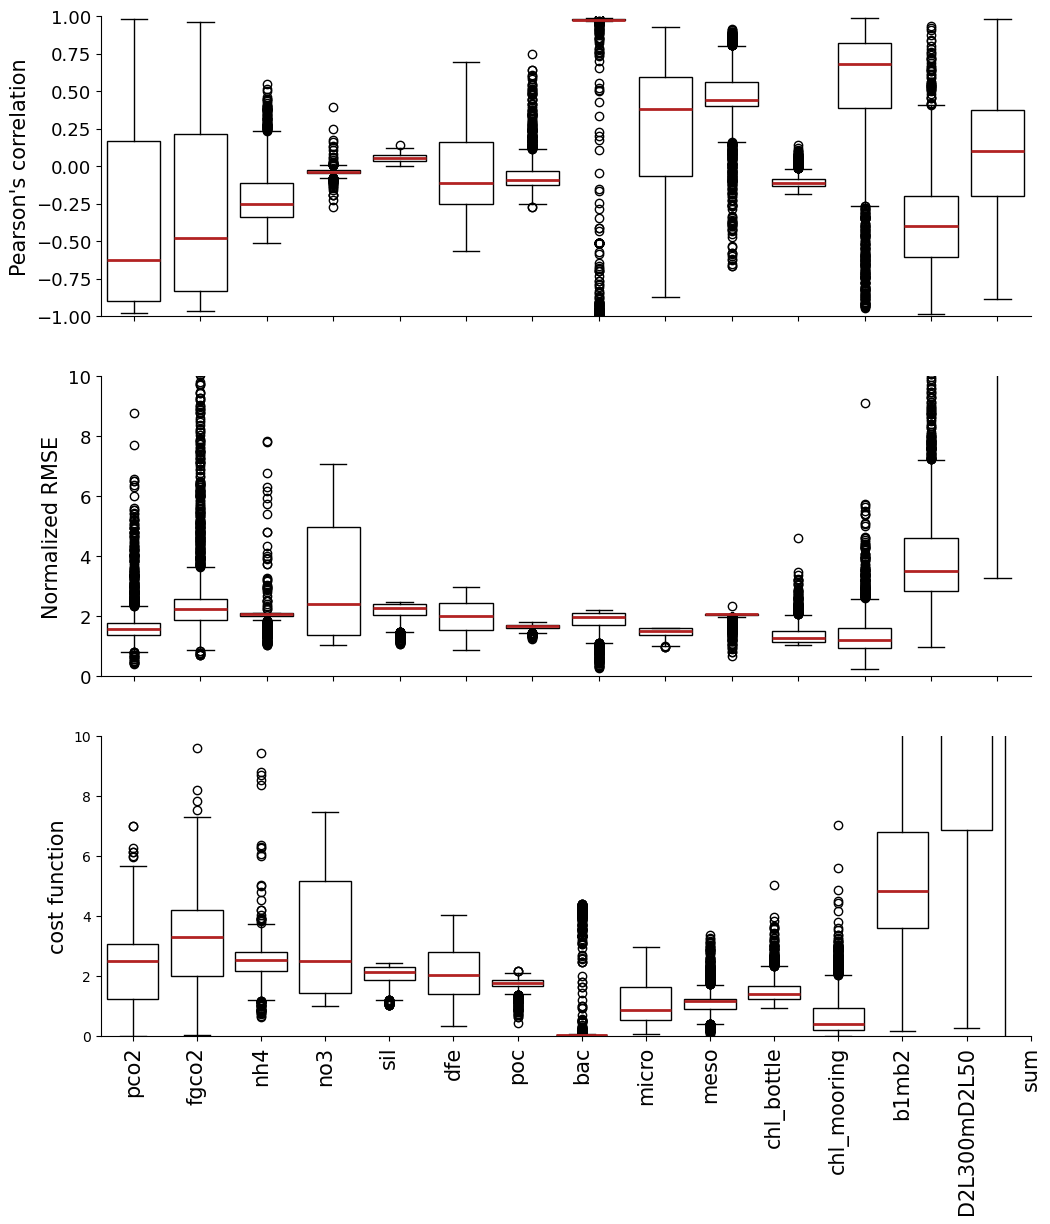

In [6]:
fstic = 13
fslab = 15

fig = plt.figure(figsize=(12,15))
gs = GridSpec(3,1)

ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[1,0])
ax3 = plt.subplot(gs[2,0])
ax1.spines[['top','right']].set_visible(False)
ax2.spines[['top','right']].set_visible(False)
ax3.spines[['top','right']].set_visible(False)
ax1.tick_params(labelsize=fstic, labelbottom=False)
ax2.tick_params(labelsize=fstic, labelbottom=False)
ax2.tick_params(labelsize=fstic)

box1 = ax1.boxplot(corr, positions=np.arange(0,len(targets),1), widths=0.8, patch_artist=True)
box2 = ax2.boxplot(nrmse, positions=np.arange(0,len(targets),1), widths=0.8, patch_artist=True)
box3 = ax3.boxplot(cost, positions=np.arange(0,len(targets),1), widths=0.8, patch_artist=True)

# Apply colors to each box
for patch in box1['boxes']:
    patch.set_facecolor('w')
for patch in box2['boxes']:
    patch.set_facecolor('w')
for patch in box3['boxes']:
    patch.set_facecolor('w')
for median in box1['medians']:
    median.set(color='firebrick', linewidth=2)
for median in box2['medians']:
    median.set(color='firebrick', linewidth=2)
for median in box3['medians']:
    median.set(color='firebrick', linewidth=2)

ax1.set_xlim(-0.5,len(targets)-1.5)
ax2.set_xlim(-0.5,len(targets)-1.5)
ax3.set_xlim(-0.5,len(targets)-1.5)

#ax2.set_yscale('log')

ax1.set_ylabel("Pearson's correlation", fontsize=fslab)
ax2.set_ylabel("Normalized RMSE", fontsize=fslab)
ax3.set_ylabel("cost function", fontsize=fslab)

ax3.set_xticks(np.arange(0,len(targets),1), targets, fontsize=fslab, rotation=90)

plt.subplots_adjust(bottom=0.2)

ax1.set_ylim(-1,1)
ax2.set_ylim(0,10)
ax3.set_ylim(0,10)


In [7]:
%%time
    
os.chdir(wrkdir)
os.getcwd()


CPU times: user 92 μs, sys: 0 ns, total: 92 μs
Wall time: 96.1 μs


'/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data'

In [8]:
%%time

fig.savefig("../figures/sensitivity_analysis_corr_nrmse_costfunction.png", dpi=300)
fig.savefig("../figures/sensitivity_analysis_corr_nrmse_costfunction.pdf", dpi=300)
fig.savefig("../figures/sensitivity_analysis_corr_nrmse_costfunction_transparent.png", dpi=300, transparent=True)


CPU times: user 2.72 s, sys: 175 ms, total: 2.9 s
Wall time: 3.43 s


## Train a Gaussian Process Regression model on the output

### start a dask client cluster

In [ ]:
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=56, threads_per_worker=1, memory_limit="16GB")
client  = Client(cluster)
client  # shows dashboard link


### train GPR on the normalized RMSE

In [17]:
%%time

### format the input data to the GPR model
X.columns = list(range(87))

tarcols = nrmse.columns

Y = np.zeros((2048, len(tarcols)))
for i, target in enumerate(tarcols):
    Y[:,i] = rmse[target]
    # Normalising RMSE values (RMSE - min(RMSE)/max(RMSE) - min(RMSE))
    Y[:,i]=(Y[:,i]-Y[:,i].min())/(Y[:,i].max()-Y[:,i].min())

Y

CPU times: user 0 ns, sys: 12.5 ms, total: 12.5 ms
Wall time: 8.41 ms


array([[1.02461301e-01, 5.97895187e-02, 2.78632876e-02, ...,
        9.55037745e-02, 9.40814439e-11, 9.40882878e-11],
       [2.35176112e-01, 1.96524520e-01, 2.96820648e-02, ...,
        3.07480355e-01, 1.10941282e-15, 2.55880297e-14],
       [1.64359308e-01, 1.28777197e-01, 1.83439414e-02, ...,
        8.61361748e-01, 1.32038276e-15, 1.65260174e-14],
       ...,
       [1.44787273e-01, 1.04041521e-01, 2.87643376e-02, ...,
        1.21747159e-01, 8.52980135e-15, 1.89283414e-14],
       [9.65844889e-02, 4.99649195e-02, 2.97372307e-02, ...,
        1.45844133e-01, 1.06230903e-15, 1.27747143e-14],
       [1.16068805e-01, 8.10495990e-02, 4.76538477e-03, ...,
        3.47560928e-01, 1.09243282e-15, 1.05340617e-14]])

In [18]:
%%time

targets = ['surface pCO$_2$', \
               'air-sea flux of CO$_2$', \
               'bottle NH$_4$', \
               'Argo NO$_3$', \
               'bottle Si(OH)$_4$', \
               'bottle dFe', \
               'Argo POC', \
               'Spring bacteria', \
               '0-200m mean micro-zoo', \
               '0-200m mean meso-zoo', \
               'Argo chlorophyll', \
               'mooring chlorophyll', \
               'B1 minus B2', \
               'D:L at 300m minus D:L at 50m']


CPU times: user 6 μs, sys: 20 μs, total: 26 μs
Wall time: 47 μs


In [19]:
n_vars   = len(targets)
n_params = len(X.columns)
N        = len(X)

print(n_vars, n_params, N)

14 87 2048


In [20]:
%%time

from sklearn.model_selection import KFold
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning  # add this near the top
from sklearn.metrics import r2_score
from sklearn.base import clone
from joblib import Parallel, delayed, parallel_backend

import warnings
warnings.filterwarnings('ignore')

n_vars   = len(targets)
n_params = len(X.columns)
N        = len(X)

kf = KFold(n_splits=8, shuffle=True, random_state=42)
splits = list(kf.split(X))  # materialize once so workers can iterate

kernel = (ConstantKernel(1.0, (1e-3, 1e3)) *
          Matern(length_scale=np.ones(n_params),           # 1-D vector (ARD)
                 length_scale_bounds=(1e-3, 5.0), nu=1.5)
          + WhiteKernel(noise_level=1e-6,
                        noise_level_bounds=(1e-9, 1e-2)))

base_gpr = GaussianProcessRegressor(kernel=kernel,
                                    n_restarts_optimizer=5,
                                    random_state=42)

def fit_one_fold(i, f, tr, te):
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", category=ConvergenceWarning)  # if applicable
    est   = clone(base_gpr)
    est.fit(X.iloc[tr, :], Y[tr, i])
    y_hat = est.predict(X.iloc[te, :])
    r2    = r2_score(Y[te, i], y_hat)
    # return everything needed to assemble safely on the driver
    return (i, f, te, y_hat, Y[te, i], r2)

# run all (target, fold) jobs in parallel
with parallel_backend("dask"): 
    results = Parallel(prefer="processes", verbose=0)(
        delayed(fit_one_fold)(i, f, tr, te)
        for i in range(n_vars)
        for f, (tr, te) in enumerate(splits)
    )

# assemble on the driver (no race conditions)
GPR_score = np.zeros((len(splits), n_vars))
Y_PRED    = np.zeros((N, n_vars))
Y_TRUE    = np.zeros((N, n_vars))

for i, f, te, y_hat, y_true, r2 in results:
    Y_PRED[te, i]      = y_hat
    Y_TRUE[te, i]      = y_true
    GPR_score[f, i]    = r2

# per-target prints and overall R^2
for i in range(n_vars):
    print(i, targets[i], np.round(GPR_score[:, i], 3))

overall_r2 = [r2_score(Y_TRUE[:, i], Y_PRED[:, i]) for i in range(n_vars)]
print("GPR per-target R^2:", np.round(overall_r2, 3))
print("GPR mean R^2:", np.round(np.mean(overall_r2), 3))


0 surface pCO$_2$ [0.59  0.647 0.625 0.461 0.548 0.713 0.549 0.486]
1 air-sea flux of CO$_2$ [0.629 0.682 0.654 0.499 0.597 0.731 0.588 0.513]
2 bottle NH$_4$ [ 0.492 -0.831 -1.171  0.203 -1.336  0.187  0.297 -0.068]
3 Argo NO$_3$ [0.666 0.602 0.571 0.596 0.589 0.633 0.556 0.578]
4 bottle Si(OH)$_4$ [0.609 0.598 0.623 0.527 0.59  0.395 0.637 0.665]
5 bottle dFe [0.796 0.666 0.807 0.809 0.801 0.769 0.761 0.78 ]
6 Argo POC [0.639 0.518 0.641 0.588 0.525 0.513 0.641 0.621]
7 Spring bacteria [0.702 0.616 0.728 0.698 0.736 0.708 0.659 0.724]
8 0-200m mean micro-zoo [0.693 0.699 0.718 0.681 0.678 0.644 0.729 0.746]
9 0-200m mean meso-zoo [0.558 0.48  0.375 0.386 0.457 0.446 0.508 0.514]
10 Argo chlorophyll [0.625 0.528 0.582 0.598 0.602 0.64  0.573 0.547]
11 mooring chlorophyll [0.467 0.461 0.484 0.531 0.494 0.431 0.481 0.521]
12 B1 minus B2 [0.221 0.467 0.3   0.194 0.38  0.38  0.359 0.375]
13 D:L at 300m minus D:L at 50m [-2.40000000e-02 -2.34934617e+10 -1.31000000e-01 -5.22460000e+01
 -4.8

In [21]:
targets[0]

'surface pCO$_2$'

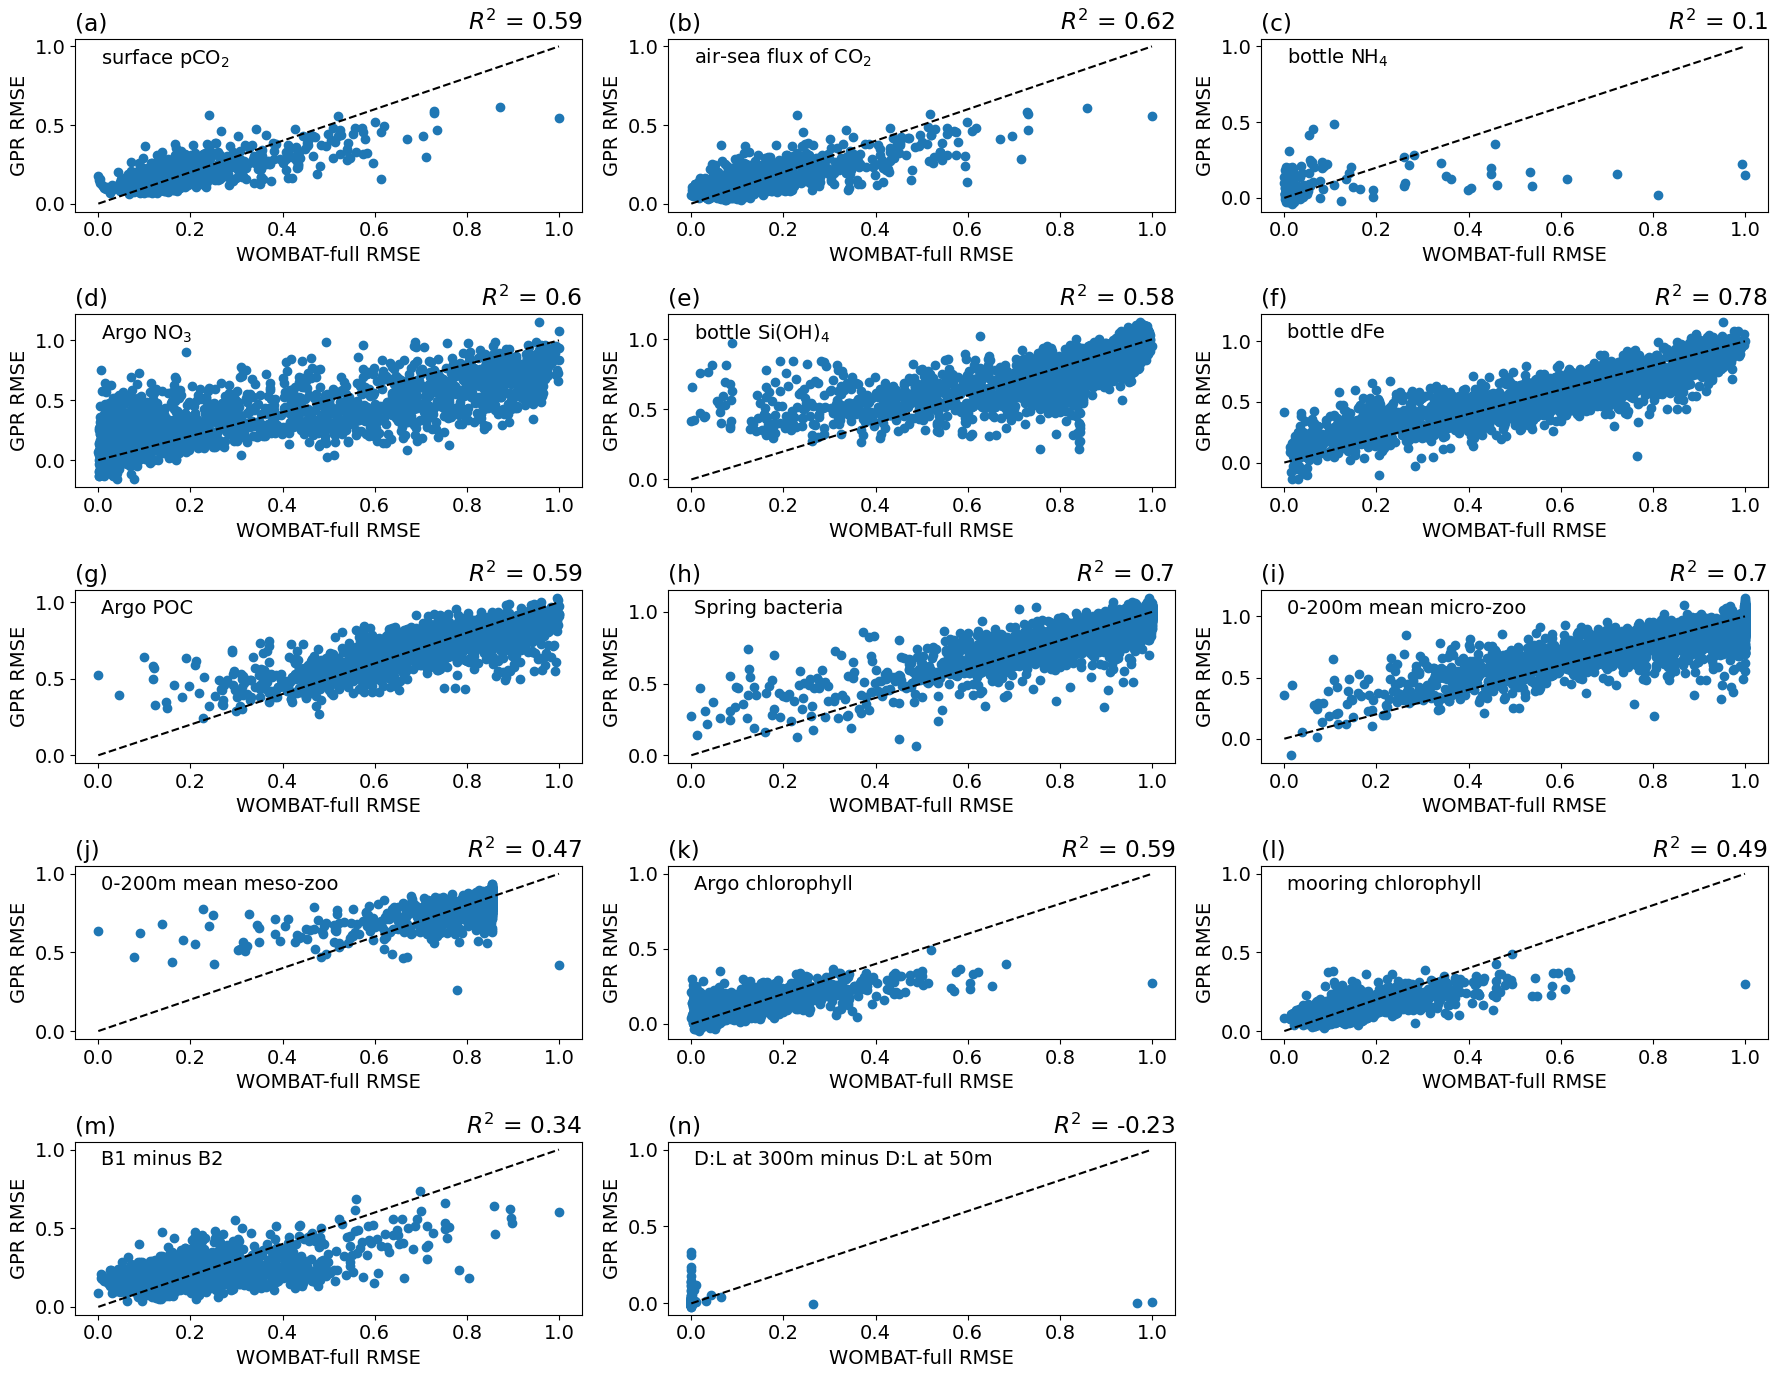

In [23]:

fig = plt.figure(figsize=(18,14))
plt.rc('font', size=14)    # fontsize of the all text
plt.rc('ytick', labelsize=14)    # fontsize of the tick labels
plt.rc('xtick', labelsize=14)
abc = ['(a) ','(b) ','(c) ',\
       '(d) ','(e) ','(f) ',\
       '(g) ','(h) ','(i) ',\
       '(j) ','(k) ','(l) ',\
       '(m) ','(n) ']

for i in range(len(targets)):
    #ax = fig.add_subplot(2,3,i+1)
    ax = fig.add_subplot(5,3,i+1)
    ax.plot((np.min(Y_TRUE[:,i]),np.max(Y_TRUE[:,i])), (np.min(Y_TRUE[:,i]), np.max(Y_TRUE[:,i])), 'k--')
    ax.scatter(Y_TRUE[:,i],Y_PRED[:,i])
    ax.set_title(abc[i], loc='left')
    ax.text(0.05,0.95, targets[i], va='top', ha='left', transform=ax.transAxes)
    ax.set_title('$R^2$ = '+str(round(r2_score(Y_TRUE[:,i],Y_PRED[:,i]),2)),
               loc='right')
    ax.set_xlabel(r'WOMBAT-full RMSE')
    ax.set_ylabel('GPR RMSE')
    #ax.set_xlim(0,1)
    #ax.set_ylim(0,1)

plt.tight_layout()
fig.savefig('../figures/sensitivity_analysis_GPRaccuracy_RMSEnormRange_2048.png', dpi=300,bbox_inches='tight')


### calculate the GPR accuracy at different numbers of experimental samples

In [ ]:
%%time

import numpy as np
import pandas as pd
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.metrics import r2_score
from sklearn.base import clone
from sklearn.model_selection import KFold
from joblib import Parallel, delayed, parallel_backend

warnings.filterwarnings('ignore')

# --- setup ---
n_vars   = len(targets)
n_params = len(X.columns)
N_total  = len(X)
N_list   = [64, 128, 256, 512, 1024, 2048]   # number of samples to test
n_splits = 8

GPR_score = np.zeros((n_vars, len(N_list), n_splits))

# --- base kernel and model ---
base_kernel = (ConstantKernel(1.0, (1e-3, 1e3)) *
               Matern(length_scale=np.ones(n_params),
                      length_scale_bounds=(1e-3, 5.0), nu=1.5)
               + WhiteKernel(noise_level=1e-6,
                             noise_level_bounds=(1e-9, 1e-2)))

base_gpr = GaussianProcessRegressor(
    kernel=base_kernel,
    n_restarts_optimizer=5,
    random_state=42
)

# --- worker function ---
def fit_one_fold(i, j, f, tr, te, N_sub):
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)

    est = clone(base_gpr)
    X_tr, X_te = X.iloc[tr, :], X.iloc[te, :]
    y_tr, y_te = Y[tr, i], Y[te, i]

    est.fit(X_tr, y_tr)
    y_hat = est.predict(X_te)
    r2 = r2_score(y_te, y_hat)
    return (i, j, f, N_sub, r2)

# --- main loop (parallelised folds and targets) ---
with parallel_backend("dask"):  # or "loky" if no Dask client
    results = Parallel(prefer="processes", verbose=0)(
        delayed(fit_one_fold)(i, j, f, tr, te, N_sub)
        for j, N_sub in enumerate(N_list)
        for i in range(n_vars)
        for f, (tr, te) in enumerate(
            KFold(n_splits=n_splits, shuffle=True, random_state=42).split(range(N_sub))
        )
    )

# --- assemble results ---
for i, j, f, N_sub, r2 in results:
    GPR_score[i, j, f] = r2

# --- report results ---
for i in range(n_vars):
    for j, N_sub in enumerate(N_list):
        mean_r2 = np.nanmean(GPR_score[i, j, :])
        print(f"{targets[i]:<25s}  N={N_sub:<5d}  mean R²={mean_r2:.3f}")


In [ ]:
fig = plt.figure(figsize=(15,9))
plt.rc('font', size=12)    # fontsize of the all text
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('xtick', labelsize=12)
abc = ['(a) ','(b) ','(c) ','(d) ','(e) ','(f) ','(g) ','(h) ', '(i) ', '(j) ', '(k) ']
for i in range(len(targets)):
    axs = fig.add_subplot(4,3,i+1)
    axs.boxplot(GPR_score[i,0:6,:].T)
    axs.set_title(abc[i] + " " + targets[i], loc='left')
    #axs.text(0.5,1.02, targets[i], va='bottom', ha='center', transform=axs.transAxes, rotation=0)
    axs.set_ylabel('$R^2$')
    axs.set_xlabel('Samples')
    axs.set_xticklabels(['64','128','256','512','1024','2048'])
    axs.set_ylim(-1.,1.0)
plt.subplots_adjust(wspace=0.4,hspace=0.4)
plt.tight_layout()
fig.savefig('../figures/sensitivity_analysis_GPRsensitivity_RMSEnormRange_2048.png', dpi=300,bbox_inches='tight')

### Do Sobol' sensitivity analysis

#### but only on targets that had an R2 score > 0.6

In [24]:
# --- report results ---
N_sub = 2048
j = -1
for i in range(n_vars):
    mean_r2 = np.nanmean(GPR_score[i, j, :])
    print(f"{targets[i]:<25s}  N={N_sub:<5d}  mean R²={mean_r2:.3f}")

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [25]:
%%time

from SALib.sample import saltelli

# Define the problem with 100 parameters
problem = {
    'num_vars': len(X.columns),
    'names': [f'P{i+1}' for i in range(len(X.columns))],
    'bounds': [[0, 1]] * len(X.columns)
}

# Generate the Saltelli sampling (1024 base samples, including 2nd-order terms)
param_values = saltelli.sample(problem, 2048, calc_second_order=True)

print(param_values.shape)
print("Max of first parameter:", max(param_values[:, 0]))


(360448, 87)
Max of first parameter: 0.999755859375
CPU times: user 10.1 s, sys: 363 ms, total: 10.4 s
Wall time: 10.1 s


In [27]:
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=14, threads_per_worker=4, memory_limit="64GB")
client  = Client(cluster)
client  # shows dashboard link


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/36589/status,
Dashboard: /proxy/36589/status,Workers: 14
Total threads: 56,Total memory: 834.47 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36969,Workers: 0
Dashboard: /proxy/36589/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45829,Total threads: 4
Dashboard: /proxy/35179/status,Memory: 59.60 GiB
Nanny: tcp://127.0.0.1:42945,


In [29]:
%%time

# --- base kernel and model ---
base_kernel = (ConstantKernel(1.0, (1e-3, 1e3)) *
               Matern(length_scale=np.ones(n_params),
                      length_scale_bounds=(1e-3, 5.0), nu=1.5)
               + WhiteKernel(noise_level=1e-6,
                             noise_level_bounds=(1e-9, 1e-2)))

base_gpr = GaussianProcessRegressor(
    kernel=base_kernel,
    n_restarts_optimizer=5,
    random_state=42
)

def sobol_for_target(i):
    """Train GPR for one target variable and compute Sobol indices."""
    import warnings
    warnings.filterwarnings("ignore")
    y = Y[:, i]
    model = gaussian_process.GaussianProcessRegressor(kernel=base_kernel, random_state=42)
    model.fit(X, y)
    y_hat = model.predict(param_values)
    Si = sobol.analyze(problem, y_hat, parallel=False, print_to_console=False)
    return (i, Si['S1'], Si['ST'], Si['S2'])

# --- parallel execution ---
with parallel_backend("dask"):
    results_sobol = Parallel(prefer="processes", verbose=10)(
        delayed(sobol_for_target)(i) for i in range(n_vars)
    )



[Parallel(n_jobs=-1)]: Using backend DaskDistributedBackend with 56 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  14 | elapsed: 19.9min remaining: 73.0min
[Parallel(n_jobs=-1)]: Done   5 out of  14 | elapsed: 20.3min remaining: 36.6min
[Parallel(n_jobs=-1)]: Done   7 out of  14 | elapsed: 20.5min remaining: 20.5min
[Parallel(n_jobs=-1)]: Done   9 out of  14 | elapsed: 22.9min remaining: 12.7min
[Parallel(n_jobs=-1)]: Done  11 out of  14 | elapsed: 29.5min remaining:  8.1min


CPU times: user 29min 15s, sys: 13min 46s, total: 43min 2s
Wall time: 39min 26s


[Parallel(n_jobs=-1)]: Done  14 out of  14 | elapsed: 39.4min finished


In [30]:
# --- gather results ---
s1 = np.zeros((n_vars, n_params))
st = np.zeros((n_vars, n_params))
s2 = np.zeros((n_vars, n_params, n_params))

for i, S1, ST, S2 in results_sobol:
    s1[i, :] = S1
    st[i, :] = ST
    s2[i, :, :] = S2
    print(f"Target {i}: mean ST = {np.nanmean(ST):.3f}")

print("\nDone computing Sobol indices for all targets.")


Target 0: mean ST = 0.019
Target 1: mean ST = 0.019
Target 2: mean ST = 0.018
Target 3: mean ST = 0.017
Target 4: mean ST = 0.014
Target 5: mean ST = 0.013
Target 6: mean ST = 0.014
Target 7: mean ST = 0.015
Target 8: mean ST = 0.014
Target 9: mean ST = 0.017
Target 10: mean ST = 0.014
Target 11: mean ST = 0.017
Target 12: mean ST = 0.019
Target 13: mean ST = 0.027

Done computing Sobol indices for all targets.


In [31]:
df = pd.DataFrame(data=st,
                    index=targets,
                    columns=problem['names'])
df_t = df.T
df_t = (df_t-df_t.min())/(df_t.max()-df_t.min())
df = df_t.T
df


,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,...,P78,P79,P80,P81,P82,P83,P84,P85,P86,P87
surface pCO$_2$,0.170421,0.821586,0.092085,0.003773,0.010619,0.068143,0.002875,0.003038,0.001703,0.003790,...,1.000000,0.000607,0.001576,0.011101,0.004052,0.000628,0.000801,0.017179,0.361777,0.022843
air-sea flux of CO$_2$,0.170548,0.848509,0.089951,0.003208,0.007331,0.063816,0.003127,0.002387,0.001578,0.003994,...,1.000000,0.000513,0.000773,0.010132,0.001920,0.000185,0.000484,0.004877,0.394806,0.024275
bottle NH$_4$,0.037672,0.000169,0.000099,0.000098,0.000545,0.000134,0.000124,0.168902,0.000895,0.000043,...,1.000000,0.043685,0.000135,0.039838,0.048080,0.000217,0.000104,0.000337,0.000331,0.000588
Argo NO$_3$,0.008107,0.038047,0.000639,0.010445,0.000153,0.072321,0.009497,0.001956,0.001561,0.016458,...,1.000000,0.003989,0.023237,0.038786,0.005925,0.000409,0.000153,0.043258,0.595539,0.058191
bottle Si(OH)$_4$,0.000537,0.016027,0.004271,0.022217,0.000083,0.125117,0.009018,0.000530,0.000357,0.001251,...,0.010847,0.000246,0.000402,0.004926,0.000625,0.000665,0.000328,0.000151,0.003120,0.000630
bottle dFe,0.000843,0.015111,0.000929,0.000862,0.000219,0.008297,0.001106,0.000508,0.000257,0.019879,...,0.048151,0.000338,0.001927,0.000661,0.000257,0.000951,0.000632,0.001747,0.057788,0.015523
Argo POC,0.006964,0.174091,0.008986,0.003581,0.000252,0.016011,0.002463,0.009301,0.009002,0.026406,...,0.302698,0.000941,0.000810,0.005365,0.001895,0.000380,0.000790,0.000459,0.134675,0.020869
Spring bacteria,0.043931,0.420240,0.017583,0.001480,0.000281,0.001482,0.000470,0.001422,0.001716,0.005718,...,0.697648,0.070693,0.018536,0.009781,0.007056,0.000364,0.011046,0.026814,1.000000,0.596930
0-200m mean micro-zoo,0.037155,0.481500,0.018915,0.001054,0.000556,0.002659,0.000403,0.000471,0.001095,0.055907,...,0.240660,0.001714,0.004867,0.004899,0.000366,0.000309,0.000388,0.000664,0.069028,0.025628
0-200m mean meso-zoo,0.005928,0.028434,0.007623,0.001587,0.000865,0.000534,0.001017,0.001687,0.001197,0.010548,...,0.048152,0.002342,0.001039,0.009639,0.000441,0.000310,0.001459,0.000412,0.000869,0.000873


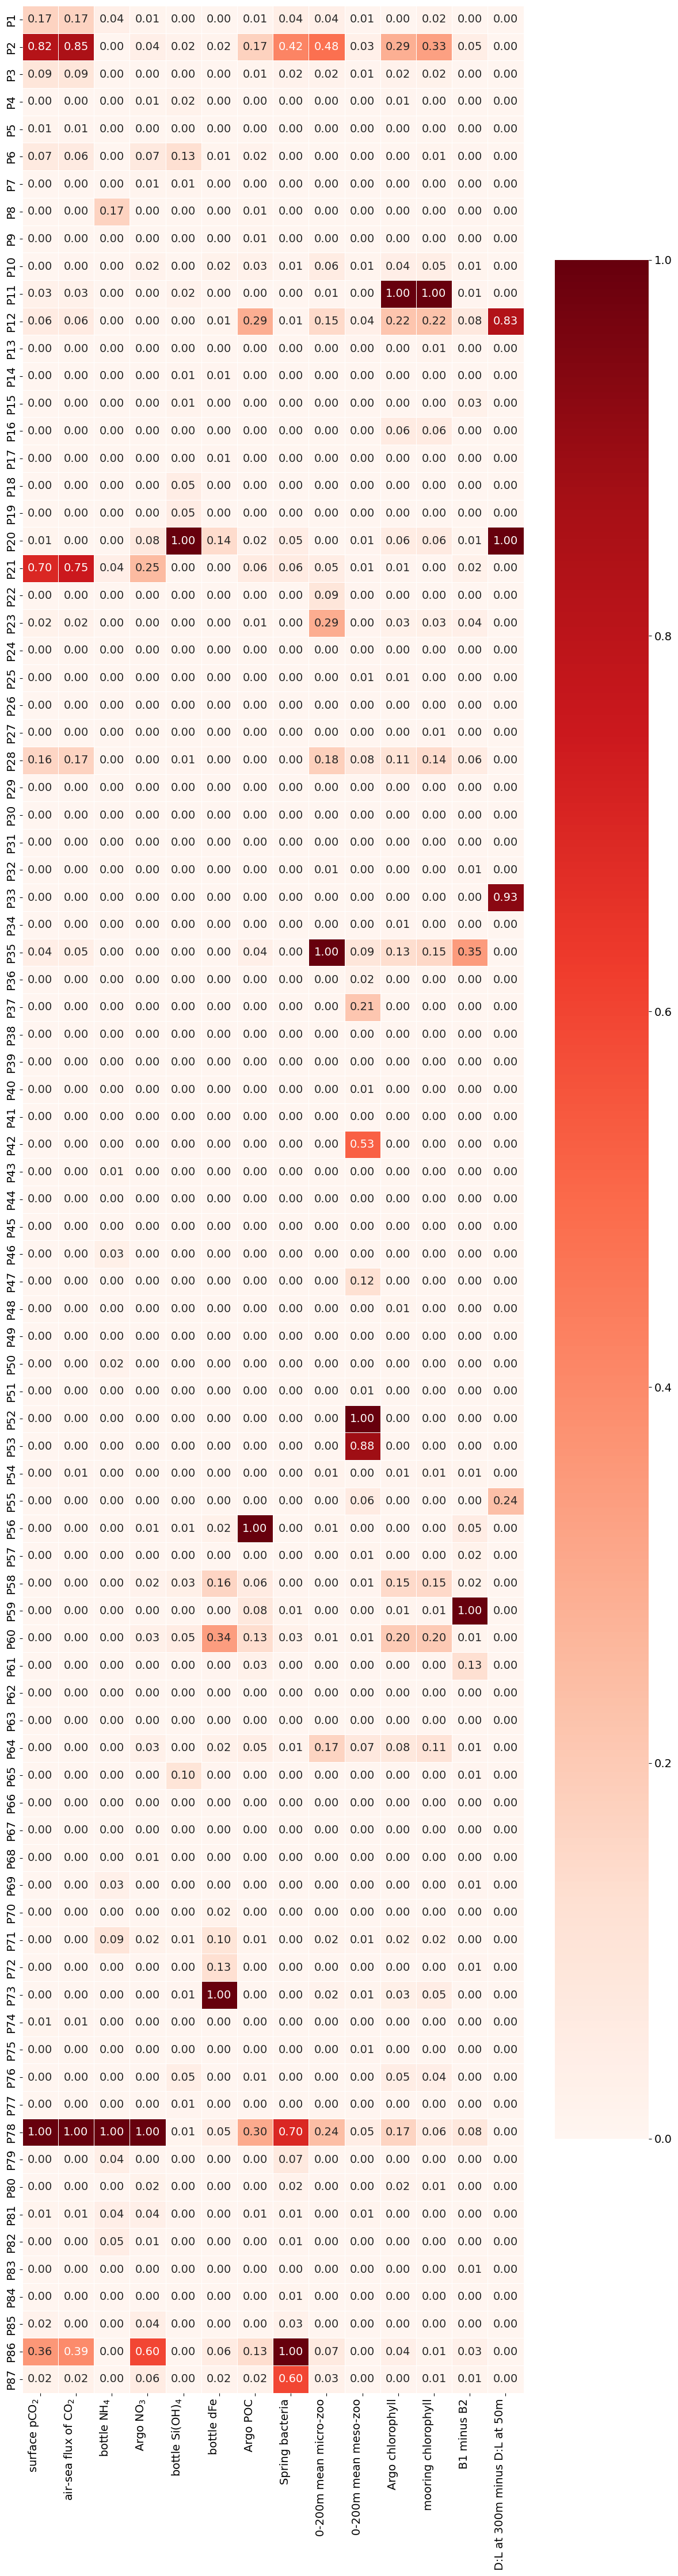

In [32]:
fig = plt.figure(figsize=(12,45))
gs = GridSpec(1,1)

ax = plt.subplot(gs[0])
ax = sns.heatmap(df.T,cmap="Reds",linewidths=.5, annot=True,fmt=".2f")
plt.xticks(rotation='horizontal')
ax.set_xticklabels(targets, rotation=90, fontsize=14, ha='right')
plt.tight_layout()


In [33]:
os.getcwd()
fig.savefig('../figures/sensitivity_analysis_heatmap_87parameters_2048exps.png', dpi=300,bbox_inches='tight')


In [34]:
var_names = ['surface pCO$_2$', \
               'air-sea flux of CO$_2$', \
               'bottle NH$_4$', \
               'Argo NO$_3$', \
               'bottle Si(OH)$_4$', \
               'bottle dFe', \
               'Argo POC', \
               'Spring bacteria', \
               '0-200m mean micro-zoo', \
               '0-200m mean meso-zoo', \
               'Argo chlorophyll', \
               'mooring chlorophyll', \
               'B1 minus B2', \
               'D:L at 300m minus D:L at 50m']

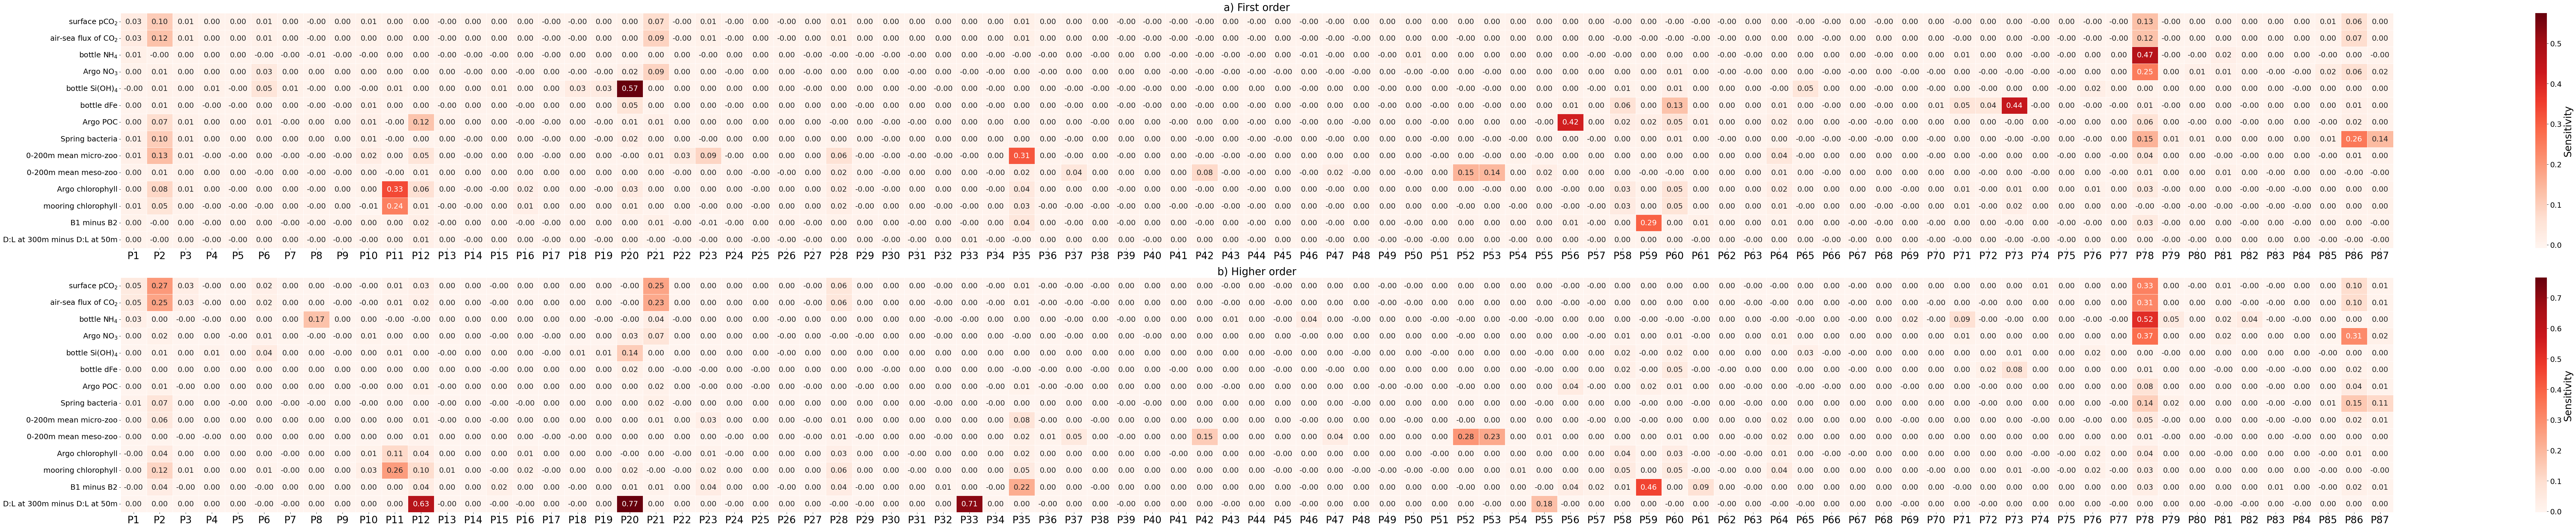

In [35]:


# First dataset processing
df1 = pd.DataFrame(data=s1, index=var_names, columns=problem['names'])
df_t1 = df1.T
#df_t1 = (df_t1 - df_t1.min()) / (df_t1.max() - df_t1.min())
df1 = df_t1.T

# Second dataset processing
df2 = pd.DataFrame(data=(st - s1), index=var_names, columns=problem['names'])
df_t2 = df2.T
#df_t2 = (df_t2 - df_t2.min()) / (df_t2.max() - df_t2.min())
df2 = df_t2.T

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(100, 18))

# Plot first heatmap (subplot a)
hmap1 = sns.heatmap(df1, cmap="Reds", linewidths=0.5, annot=True, fmt=".2f", ax=axes[0], annot_kws={"size": 18})
#axes[0].set_xticklabels(xtick_labels, rotation=90, fontsize=18, ha='right')
axes[0].set_title('a) First order', fontsize=25)
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=18)
axes[0].set_xticklabels(axes[0].get_xticklabels(), fontsize=24)

# Plot second heatmap (subplot b)
hmap2 = sns.heatmap(df2, cmap="Reds", linewidths=0.5, annot=True, fmt=".2f", ax=axes[1], annot_kws={"size": 18})
#axes[1].set_xticklabels(xtick_labels, rotation=90, fontsize=18, ha='right')
axes[1].set_title('b) Higher order', fontsize=25)
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=18)
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=24)

cbar1 = hmap1.collections[0].colorbar
cbar2 = hmap2.collections[0].colorbar
cbar1.set_label('Sensitivity', fontsize=24)
cbar1.ax.tick_params(labelsize=18)
cbar2.set_label('Sensitivity', fontsize=24)
cbar2.ax.tick_params(labelsize=18)

# Adjust layout
plt.tight_layout()
fig.savefig('../figures/sensitivity_analysis_SAresult_RMSEnormRange_2048exps.png', dpi=300,bbox_inches='tight')
fig.savefig('../figures/sensitivity_analysis_SAresult_RMSEnormRange_2048exps.pdf', dpi=300,bbox_inches='tight')